# Глава 5. Автокорреляция — упражнения

In [1]:
import os
import math
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

BASE_URL = 'https://github.com/AllenDowney/ThinkDSP/raw/master/code/'


def download_if_missing(filename, base_url=BASE_URL):
    if os.path.exists(filename):
        return
    url = base_url + filename
    print(f'Downloading {filename} ...')
    try:
        urllib.request.urlretrieve(url, filename)
    except Exception as exc:
        raise RuntimeError(
            f'Не удалось скачать {filename}. Скачайте файл вручную из {url}'
        ) from exc


for filename in [
    'thinkdsp.py',
    '28042__bcjordan__voicedownbew.wav',
    'BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv',
    '100475__iluppai__saxophone-weep.wav',
]:
    download_if_missing(filename)

from thinkdsp import read_wave, Wave, decorate

In [2]:
def serial_corr(wave, lag=1):
    """Вычисляет последовательную корреляцию для заданного лага.

    wave: thinkdsp.Wave
    lag: сдвиг в отсчётах
    """
    n = len(wave)
    if lag == 0:
        return 1.0
    if lag >= n - 1:
        return np.nan

    y1 = wave.ys[lag:]
    y2 = wave.ys[:n-lag]
    return np.corrcoef(y1, y2)[0, 1]


def autocorr_stat(wave):
    """Автокорреляция через serial_corr для лагов от 0 до половины длины."""
    lags = np.arange(len(wave.ys) // 2)
    corrs = np.array([serial_corr(wave, lag) for lag in lags])
    return lags, corrs


def autocorr_fast(wave):
    """Быстрая нормированная автокорреляция через np.correlate.

    Возвращает только неотрицательные лаги.
    """
    ys = np.asarray(wave.ys, dtype=float)
    ys = ys - ys.mean()

    corrs = np.correlate(ys, ys, mode='full')
    corrs = corrs[len(ys)-1:].copy()

    # Поправка на уменьшающееся число перекрывающихся отсчётов.
    lengths = np.arange(len(ys), 0, -1)
    corrs /= lengths

    # Нормировка: corr[0] = 1.
    if corrs[0] != 0:
        corrs /= corrs[0]

    lags = np.arange(len(corrs))
    return lags, corrs


def simple_peak_lags(values):
    """Индексы локальных максимумов одномерного массива."""
    values = np.asarray(values)
    if len(values) < 3:
        return np.array([], dtype=int)
    return np.where((values[1:-1] > values[:-2]) & (values[1:-1] >= values[2:]))[0] + 1

In [3]:
def estimate_fundamental(segment, low_freq=70, high_freq=1500, min_corr=0.05, return_details=False):
    """Оценивает основную частоту сегмента по пику автокорреляции.

    Параметры:
    - segment: короткий Wave-сегмент;
    - low_freq, high_freq: диапазон поиска частоты в Гц;
    - min_corr: минимальная корреляция для локального пика;
    - return_details: если True, возвращает частоту и диагностические данные.

    Идея: period = lag / framerate, поэтому frequency = framerate / lag.
    """
    lags, corrs = autocorr_fast(segment)
    framerate = segment.framerate

    # Перевод диапазона частот в диапазон лагов.
    low_lag = max(1, int(np.floor(framerate / high_freq)))
    high_lag = min(len(corrs) - 1, int(np.ceil(framerate / low_freq)))

    if high_lag <= low_lag:
        result = np.nan
        details = {'lag': np.nan, 'corr': np.nan, 'lags': lags, 'corrs': corrs}
        return (result, details) if return_details else result

    window = corrs[low_lag:high_lag + 1]
    peaks = simple_peak_lags(window) + low_lag
    peaks = peaks[corrs[peaks] >= min_corr]

    if len(peaks) == 0:
        lag = int(np.argmax(window)) + low_lag
    else:
        lag = int(peaks[np.argmax(corrs[peaks])])

    frequency = framerate / lag
    details = {'lag': lag, 'corr': corrs[lag], 'lags': lags, 'corrs': corrs,
               'low_lag': low_lag, 'high_lag': high_lag, 'peaks': peaks}
    return (frequency, details) if return_details else frequency


def track_pitch(wave, start=0.0, stop=None, step=0.05, duration=0.01,
                low_freq=70, high_freq=1500, min_corr=0.05):
    """Оценивает высоту тона в последовательности коротких сегментов."""
    if stop is None:
        # У thinkdsp.Wave обычно есть duration, но оставим запасной вариант.
        stop = getattr(wave, 'duration', wave.ts[-1] - wave.ts[0]) - duration

    starts = np.arange(start, stop, step)
    ts = []
    freqs = []

    for s in starts:
        segment = wave.segment(start=s, duration=duration)
        if len(segment) < 4:
            continue
        freq = estimate_fundamental(segment, low_freq=low_freq,
                                    high_freq=high_freq, min_corr=min_corr)
        ts.append(s + duration / 2)
        freqs.append(freq)

    return np.array(ts), np.array(freqs)


## Упражнение 5.1

**Задание.** Воспользоваться автокорреляцией для разных начальных моментов сегмента вокального чирпа и оценить высоту тона.



In [4]:
chirp = read_wave('28042__bcjordan__voicedownbew.wav')
chirp.normalize()
chirp.make_audio()

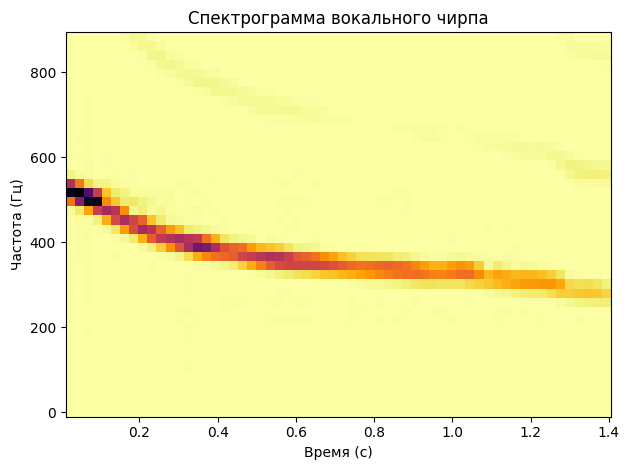

In [5]:
chirp.make_spectrogram(seg_length=2048).plot(high=900)
decorate(xlabel='Время (с)', ylabel='Частота (Гц)', title='Спектрограмма вокального чирпа')

In [6]:
# Оценим частоту в нескольких точках времени.
duration = 0.01
starts = np.arange(0.10, 1.31, 0.20)
rows = []

for start in starts:
    segment = chirp.segment(start=start, duration=duration)
    freq, details = estimate_fundamental(segment, low_freq=200, high_freq=700,
                                         return_details=True)
    rows.append({
        'start_s': round(start, 3),
        'mid_s': round(start + duration / 2, 3),
        'lag_samples': details['lag'],
        'autocorr_at_lag': round(details['corr'], 3),
        'frequency_hz': round(freq, 1),
    })

pitch_table = pd.DataFrame(rows)
display(pitch_table)

,start_s,mid_s,lag_samples,autocorr_at_lag,frequency_hz
0,0.1,0.105,91,0.988,484.6
1,0.3,0.305,219,1.005,201.4
2,0.5,0.505,121,0.975,364.5
3,0.7,0.705,127,0.994,347.2
4,0.9,0.905,133,1.000,331.6
5,1.1,1.105,140,0.961,315.0
6,1.3,1.305,153,0.981,288.2


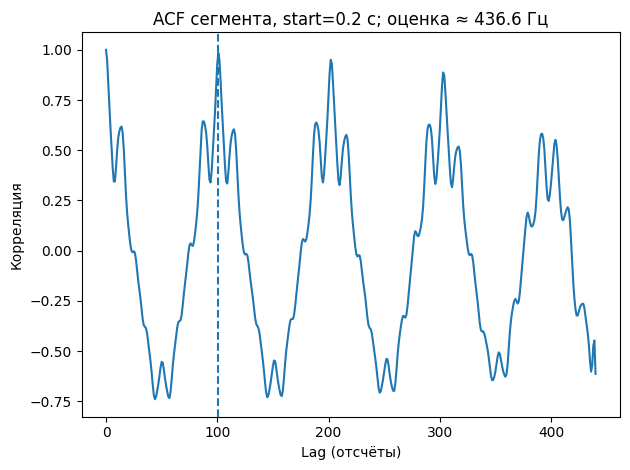

In [7]:
# Пример автокорреляции для одного сегмента.
start = 0.2
segment = chirp.segment(start=start, duration=duration)
freq, details = estimate_fundamental(segment, low_freq=200, high_freq=700,
                                     return_details=True)

plt.plot(details['lags'], details['corrs'])
plt.axvline(details['lag'], linestyle='--')
decorate(xlabel='Lag (отсчёты)', ylabel='Корреляция',
         title=f'ACF сегмента, start={start:.1f} c; оценка ≈ {freq:.1f} Гц')

**Вывод по 5.1.** При увеличении `start` оценённая частота должна уменьшаться: это соответствует нисходящему вокальному чирпу. Значения могут слегка отличаться из-за выбора длины сегмента и диапазона лагов.


## Упражнение 5.2

**Задание.** Инкапсулировать оценку основной частоты в функцию `estimate_fundamental` и проверить её, наложив оценки частоты на спектрограмму.

Функция уже определена выше. Теперь применим её ко всей записи.


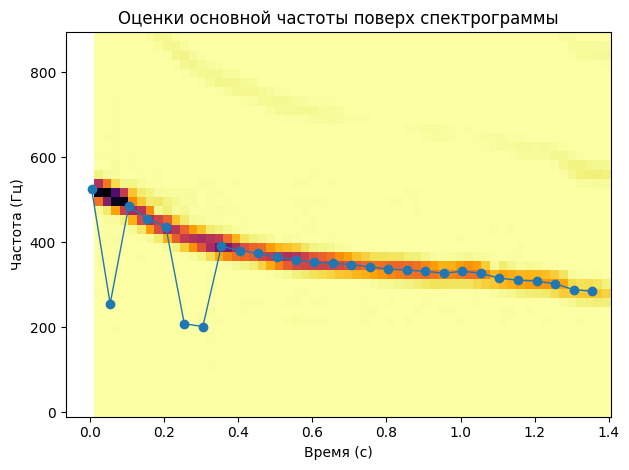

In [8]:
ts, freqs = track_pitch(chirp, start=0.0, stop=1.4, step=0.05,
                        duration=0.01, low_freq=200, high_freq=700)

chirp.make_spectrogram(seg_length=2048).plot(high=900)
plt.plot(ts, freqs, marker='o', linewidth=1)
decorate(xlabel='Время (с)', ylabel='Частота (Гц)',
         title='Оценки основной частоты поверх спектрограммы')

In [9]:
track_table = pd.DataFrame({
    'time_s': np.round(ts, 3),
    'estimated_frequency_hz': np.round(freqs, 1),
})
display(track_table.head(10))
display(track_table.tail(10))

,time_s,estimated_frequency_hz
0,0.005,525.0
1,0.055,254.9
2,0.105,484.6
3,0.155,454.6
4,0.205,436.6
5,0.255,208.0
6,0.305,201.4
7,0.355,390.3
8,0.405,380.2
9,0.455,373.7


,time_s,estimated_frequency_hz
18,0.905,331.6
19,0.955,326.7
20,1.005,331.6
21,1.055,326.7
22,1.105,315.0
23,1.155,310.6
24,1.205,308.4
25,1.255,302.1
26,1.305,288.2
27,1.355,284.5


**Вывод по 5.2.** Точки должны идти вдоль нижней яркой полосы спектрограммы — это и есть основная частота. На краях записи или в слабых/шумных местах возможны выбросы.


## Упражнение 5.3

**Задание.** Для исторических цен Bitcoin вычислить автокорреляционную функцию. Быстро ли она спадает? Есть ли признаки периодичности?

Ниже построены две ACF:

1. для самих цен закрытия;
2. для дневных изменений цены.



In [10]:
df = pd.read_csv('BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv', parse_dates=[0])
df.head()

,Currency,Date,Closing Price (USD),24h Open (USD),24h High (USD),24h Low (USD)
0,BTC,2013-10-01,123.65499,124.30466,124.75166,122.56349
1,BTC,2013-10-02,125.45500,123.65499,125.75850,123.63383
2,BTC,2013-10-03,108.58483,125.45500,125.66566,83.32833
3,BTC,2013-10-04,118.67466,108.58483,118.67500,107.05816
4,BTC,2013-10-05,121.33866,118.67466,121.93633,118.00566


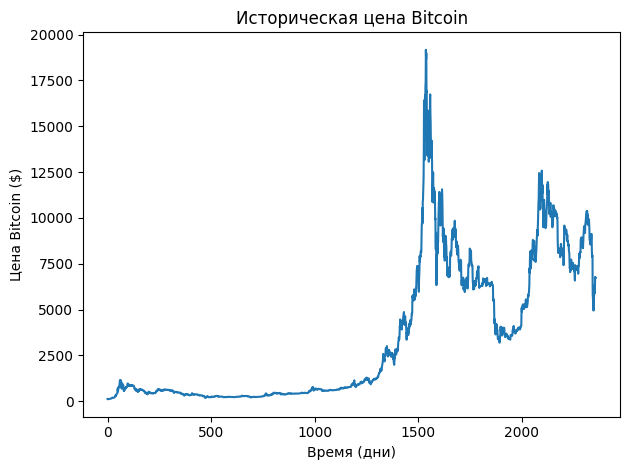

In [11]:
price = df['Closing Price (USD)'].astype(float).to_numpy()
price_wave = Wave(price, ts=np.arange(len(price)), framerate=1)

price_wave.plot()
decorate(xlabel='Время (дни)', ylabel='Цена Bitcoin ($)',
         title='Историческая цена Bitcoin')

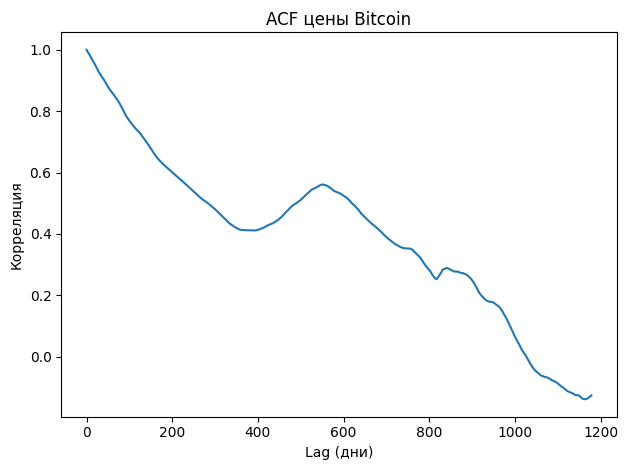

In [12]:
lags_price, corrs_price = autocorr_stat(price_wave)

plt.plot(lags_price, corrs_price)
decorate(xlabel='Lag (дни)', ylabel='Корреляция',
         title='ACF цены Bitcoin')

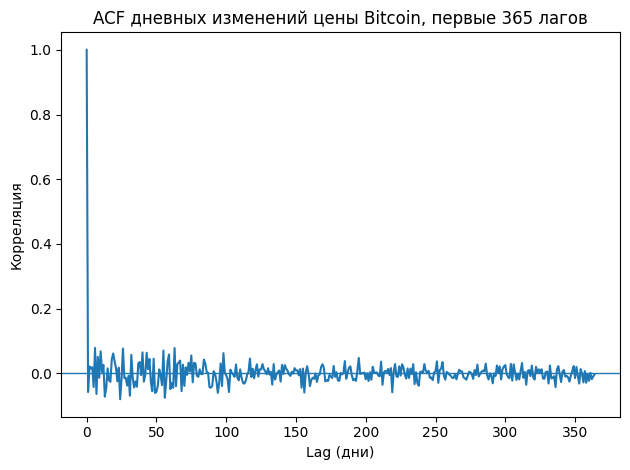

In [13]:
# Для сравнения: автокорреляция дневных изменений цены.
changes = np.diff(price)
changes_wave = Wave(changes, ts=np.arange(len(changes)), framerate=1)

lags_changes, corrs_changes = autocorr_stat(changes_wave)

plt.plot(lags_changes[:365], corrs_changes[:365])
plt.axhline(0, linewidth=1)
decorate(xlabel='Lag (дни)', ylabel='Корреляция',
         title='ACF дневных изменений цены Bitcoin, первые 365 лагов')

In [14]:
print(f'Корреляция цены при lag=1: {corrs_price[1]:.3f}')
print(f'Корреляция изменения цены при lag=1: {corrs_changes[1]:.3f}')
print(f'Максимальная |ACF| изменений после lag=1 и до lag=365: '
      f'{np.nanmax(np.abs(corrs_changes[2:365])):.3f}')

Корреляция цены при lag=1: 0.998
Корреляция изменения цены при lag=1: -0.058
Максимальная |ACF| изменений после lag=1 и до lag=365: 0.080


**Вывод по 5.3.** ACF самих цен обычно спадает медленно: это связано с трендом и нестационарностью ряда. У дневных изменений корреляции должны быть намного ближе к нулю и без устойчивых повторяющихся пиков. Поэтому явных признаков периодичности процесса обычно не видно.


## Упражнение 5.4

**Задание.** Разобраться с примером подавленной основной частоты (`saxophone.ipynb`) и использовать автокорреляцию для анализа другого сегмента.

В спектре может быть слабая или почти отсутствующая фундаментальная частота, но периодичность формы волны остаётся. Поэтому автокорреляция часто находит воспринимаемую высоту тона лучше, чем простой поиск максимального пика спектра.


In [15]:
sax = read_wave('100475__iluppai__saxophone-weep.wav')
sax.normalize()
sax.make_audio()

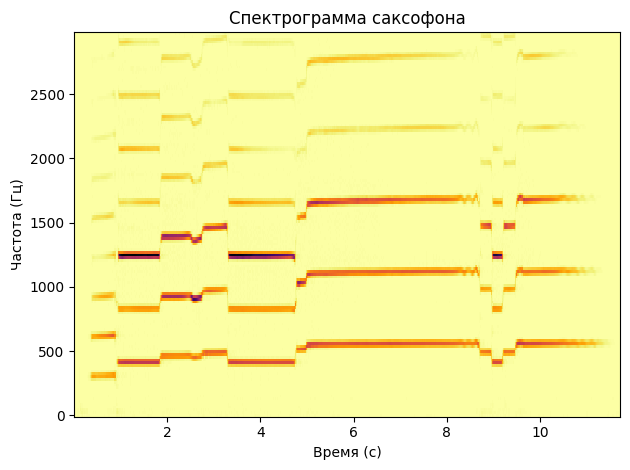

In [16]:
sax.make_spectrogram(seg_length=2048).plot(high=3000)
decorate(xlabel='Время (с)', ylabel='Частота (Гц)',
         title='Спектрограмма саксофона')

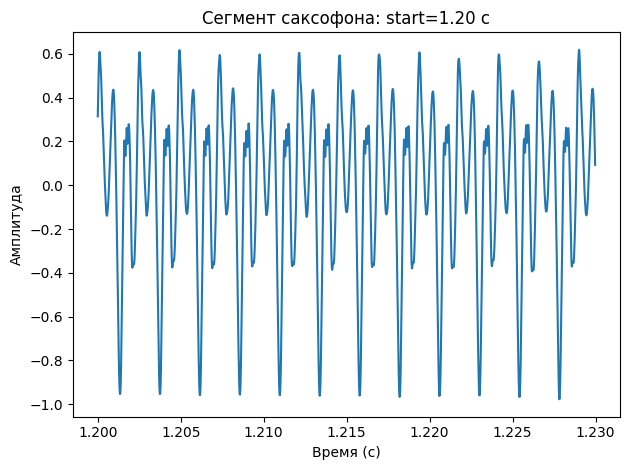

In [17]:
# Выберите другой start, чтобы проверить другой сегмент.
start = 1.20
duration = 0.03
segment = sax.segment(start=start, duration=duration)
segment.plot()
decorate(xlabel='Время (с)', ylabel='Амплитуда',
         title=f'Сегмент саксофона: start={start:.2f} c')

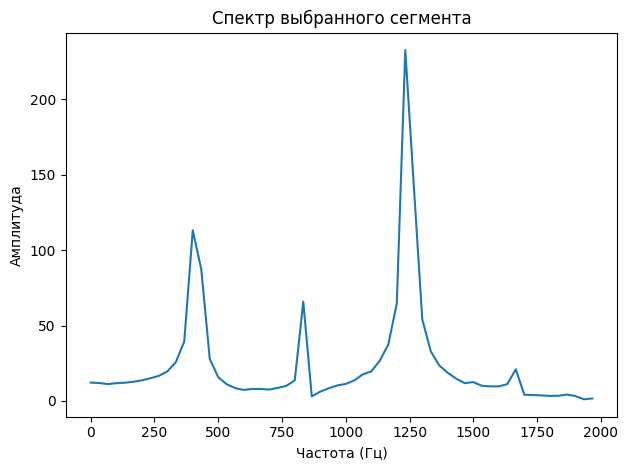

In [18]:
# Спектр сегмента: максимальный пик спектра не обязательно равен воспринимаемой основной частоте.
spectrum = segment.make_spectrum()
spectrum.plot(high=2000)
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда',
         title='Спектр выбранного сегмента')

lag = 106 отсчётов
period = 2.40 мс
estimated fundamental = 416.0 Гц


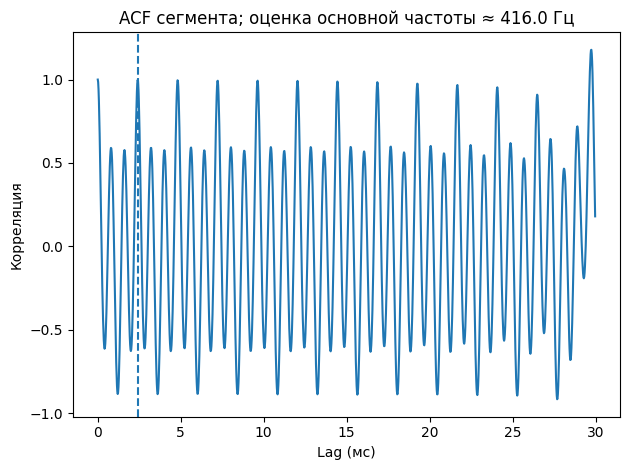

In [19]:
freq, details = estimate_fundamental(segment, low_freq=80, high_freq=1200,
                                     min_corr=0.05, return_details=True)

plt.plot(details['lags'] / segment.framerate * 1000, details['corrs'])
plt.axvline(details['lag'] / segment.framerate * 1000, linestyle='--')
decorate(xlabel='Lag (мс)', ylabel='Корреляция',
         title=f'ACF сегмента; оценка основной частоты ≈ {freq:.1f} Гц')

print(f'lag = {details["lag"]} отсчётов')
print(f'period = {details["lag"] / segment.framerate * 1000:.2f} мс')
print(f'estimated fundamental = {freq:.1f} Гц')

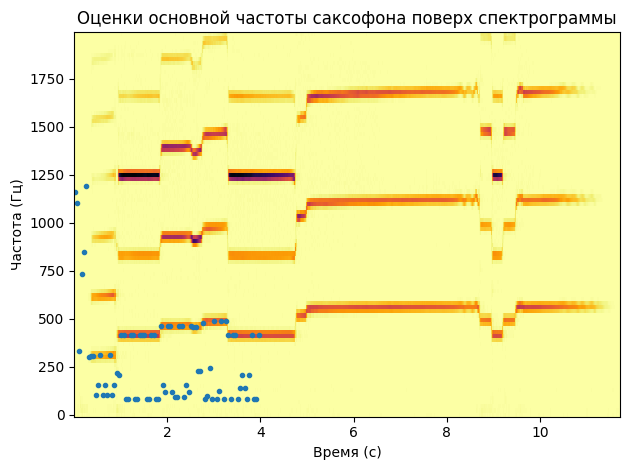

In [20]:
# Трекинг высоты тона по фрагменту записи саксофона.
# При необходимости измените stop, чтобы анализировать более длинный/короткий участок.
stop = min(getattr(sax, 'duration', sax.ts[-1] - sax.ts[0]) - duration, 4.0)
ts_sax, freqs_sax = track_pitch(sax, start=0.0, stop=stop, step=0.05,
                                duration=duration, low_freq=80, high_freq=1200,
                                min_corr=0.05)

sax.make_spectrogram(seg_length=2048).plot(high=2000)
plt.plot(ts_sax, freqs_sax, marker='.', linewidth=0)
decorate(xlabel='Время (с)', ylabel='Частота (Гц)',
         title='Оценки основной частоты саксофона поверх спектрограммы')

**Вывод по 5.4.** Если фундаментальная частота подавлена в спектре, это не означает, что период исчез. Автокорреляция ищет повторяемость формы волны во времени; поэтому пик ACF даёт период и, соответственно, воспринимаемую высоту тона.

